# Step 8-A: 사용자 대면 XAI

**포함 모듈**
- 8-A0 기회비용 시뮬레이션
- 8-A1 Risk Score → CAL 배분 흐름
- 8-A4 손실 감내도 (MDD → 금액 환산)
- 8-A5 내재 λ 성향 지표
- 8-A6 MVP vs Sortino-max 비교

> Risk Score 자체 산출(하위변수 분해, Big Five)은 별도 팀 담당 — 여기서는 **Risk Score를 외생변수로 입력**받아 사용합니다.

## 환경 설정 & 공통 데이터 로드

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
from step6_cal import score_to_w_risky, compute_cal_allocation

plt.rcParams['font.family']       = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 110

S5_DIR  = ROOT / 'results' / 'step5'
S7_DIR  = ROOT / 'results' / 'step7'
CUR_DIR = ROOT / 'results' / 'current'

# ── 공통 데이터 ──
perf_con = pd.read_parquet(S5_DIR / 'portfolio_performance_constrained.parquet')
perf_mvp = pd.read_parquet(S5_DIR / 'portfolio_performance_mvp.parquet')
lam_df   = pd.read_parquet(S7_DIR / 'lambda_implied.parquet').reset_index()
cur_w    = pd.read_csv(CUR_DIR / 'current_weights_sortino.csv', index_col=0)['weight']
cur_mvp  = pd.read_csv(CUR_DIR / 'current_weights_mvp.csv',    index_col=0)['weight']

cum_con = (1 + perf_con['cum_ret_pct'] / 100).cumprod()
cum_mvp = (1 + perf_mvp['cum_ret_pct'] / 100).cumprod()

def _mdd(s): return float(((s - s.cummax()) / s.cummax()).min())

MDD_CON     = _mdd(cum_con)
MDD_MVP     = _mdd(cum_mvp)
ANN_RET_CON = float(cum_con.iloc[-1] ** (4 / len(cum_con)) - 1)
ANN_RET_MVP = float(cum_mvp.iloc[-1] ** (4 / len(cum_mvp)) - 1)
BENCH_RET   = 0.025   # 원리금보장형 대표 연수익률

SLOTS_GROUPED = {
    '국내주식': ['국내주식_코스피', '국내주식_코스닥'],
    '미국주식': ['미국주식_SP500', '미국주식_나스닥'],
    '신흥국':   ['신흥국_인도', '신흥국_중국'],
    '국내채권': ['국내채권_국고채단중기','국내채권_국고채장기','국내채권_회사채','국내채권_종합'],
    '해외채권': ['해외채권_미국국채'],
    '원자재':   ['원자재_금'],
    '무위험':   ['무위험(현금성)'],
}
GROUP_COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1']
DISCLAIMER   = "※ 투자 참고 정보입니다. 미래 수익을 보장하지 않으며, 투자 결정은 투자자 본인이 합니다."

print(f"Sortino-max: 연환산 {ANN_RET_CON*100:.2f}%  MDD {MDD_CON*100:.2f}%")
print(f"MVP        : 연환산 {ANN_RET_MVP*100:.2f}%  MDD {MDD_MVP*100:.2f}%")
print(f"λ_implied 데이터: {len(lam_df)}행, Risk Score: {sorted(lam_df['risk_score'].unique())}")

▶ Step 5 결과 로드...
  분기 수: 38개 (2016-01-29 ~ 2025-01-16)

【 Risk Score → w_risky 매핑 (일부) 】
 risk_score  w_risky  w_riskfree  위험군
        1.0      0.0         1.0 초보수형
        3.0      0.2         0.8  보수형
        5.0      0.4         0.6  중립형
        7.0      0.6         0.4  성장형
        9.0      0.7         0.3  공격형
       10.0      0.7         0.3  공격형

【 최근 리밸런싱 (2025-01-16) 대표 Risk Score별 최종 배분 (%) 】
슬롯                           RS 2.0 RS 4.0 RS 6.0 RS 7.2 RS 9.0
------------------------------------------------------------------------------
국내주식_코스피                          0.1%      0.3%      0.5%      0.6%      0.7%
국내주식_코스닥                          2.7%      8.1%     13.5%     16.5%     18.9%
미국주식_SP500                        1.0%      3.0%      5.0%      6.1%      7.0%
미국주식_나스닥                          4.0%     12.0%     20.0%     24.4%     28.0%
신흥국_인도                            0.1%      0.3%      0.5%      0.6%      0.7%
신흥국_중국                            1.4%      4.2%      7

## 투자자 입력값 (외생변수)

> **여기만 수정하면 아래 모든 차트가 자동으로 갱신됩니다.**

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  투자자 입력값  ← 이 셀만 수정하세요
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RISK_SCORE      = 7.2    # 설문 합산 결과 (1~10, 별도 팀 산출)
CURRENT_BALANCE = 10000  # 현재 퇴직연금 적립금 (만원) — 1억
ANNUAL_SALARY   = 6000   # 연봉 (만원) — 6천만
YEARS_TO_RETIRE = 25     # 은퇴까지 남은 연수

# ── 파생값 (수정 불필요) ──
W_RISKY   = score_to_w_risky(RISK_SCORE)
FINAL_W   = compute_cal_allocation(RISK_SCORE, cur_w.copy())
TIER_MAP  = {(0,2):'초보수형',(2,4):'보수형',(4,6):'중립형',(6,8):'성장형',(8,10):'공격형'}
TIER      = next(v for (lo,hi),v in TIER_MAP.items() if lo <= RISK_SCORE < hi) \
            if RISK_SCORE < 10 else '공격형'

print(f"Risk Score  : {RISK_SCORE}점 → {TIER}")
print(f"w_risky     : {W_RISKY*100:.0f}%  (무위험 {(1-W_RISKY)*100:.0f}%)")
print(f"적립금      : {CURRENT_BALANCE/1e4:.1f}억원")
print(f"연봉        : {ANNUAL_SALARY/1e4:.1f}억원  (월 {ANNUAL_SALARY/12/1e4:.2f}억)")
print(f"은퇴까지    : {YEARS_TO_RETIRE}년")

Risk Score  : 7.2점 → 성장형
w_risky     : 61%  (무위험 39%)
적립금      : 1.0억원
연봉        : 0.6억원  (월 0.05억)
은퇴까지    : 25년


---
## 8-A0 기회비용 시뮬레이션

원리금보장형으로 방치했을 때와 참고 포트폴리오를 활용했을 때의 은퇴 시점 예상 자산 차이를 금액으로 제시합니다.

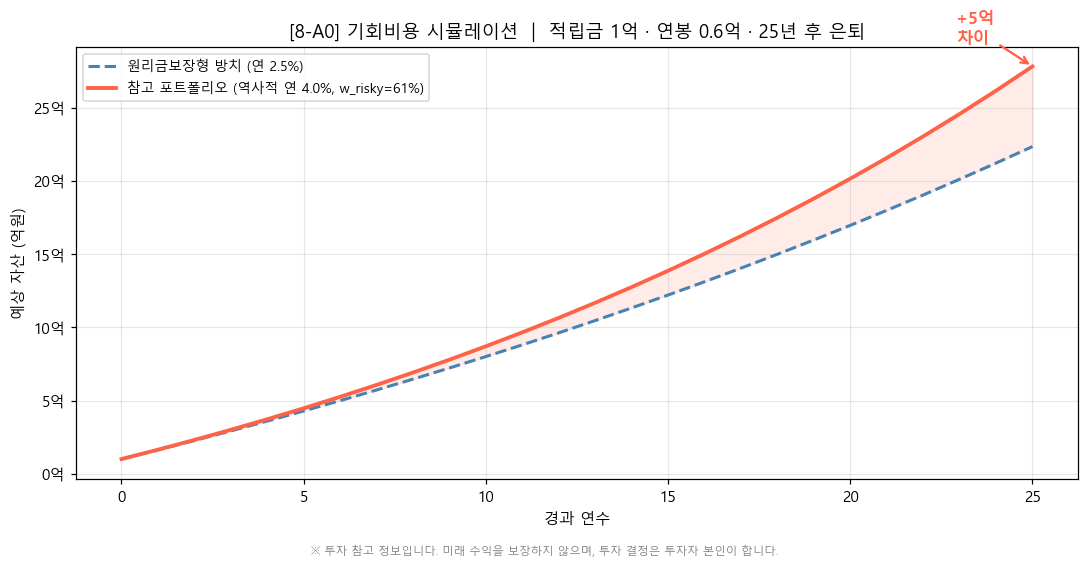

원리금보장형  : 22.3억원
참고 포트폴리오: 27.8억원
차이 (기회비용): +5.5억원


In [3]:
def fv(balance, monthly_c, ann_r, yrs):
    """미래가치: 현재 적립금 복리 + 월 기여금 연금"""
    if ann_r < 1e-6:
        return balance + monthly_c * 12 * yrs
    return (balance * (1 + ann_r) ** yrs
            + monthly_c * ((1 + ann_r) ** yrs - 1) / (ann_r / 12))

monthly_c = ANNUAL_SALARY / 12
# CAL 적용: 위험자산 비중만큼 포트폴리오 수익률 적용
port_ret   = ANN_RET_CON * W_RISKY           # 단순 가중 (무위험 ≈ 0% 초과수익)
fv_bench   = fv(CURRENT_BALANCE, monthly_c, BENCH_RET, YEARS_TO_RETIRE)
fv_port    = fv(CURRENT_BALANCE, monthly_c, port_ret,  YEARS_TO_RETIRE)
opp_cost   = fv_port - fv_bench

yr_range   = np.arange(0, YEARS_TO_RETIRE + 1)
path_bench = [fv(CURRENT_BALANCE, monthly_c, BENCH_RET, y) for y in yr_range]
path_port  = [fv(CURRENT_BALANCE, monthly_c, port_ret,  y) for y in yr_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yr_range, [v/1e4 for v in path_bench], '--', color='steelblue', lw=2,
        label=f'원리금보장형 방치 (연 {BENCH_RET*100:.1f}%)')
ax.plot(yr_range, [v/1e4 for v in path_port],  '-',  color='tomato',    lw=2.5,
        label=f'참고 포트폴리오 (역사적 연 {port_ret*100:.1f}%, w_risky={W_RISKY*100:.0f}%)')
ax.fill_between(yr_range, [v/1e4 for v in path_bench], [v/1e4 for v in path_port],
                alpha=0.12, color='tomato')
ax.annotate(f'+{opp_cost/1e4:,.0f}억\n차이',
            xy=(YEARS_TO_RETIRE, fv_port/1e4),
            xytext=(-50, 15), textcoords='offset points',
            fontsize=11, fontweight='bold', color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
ax.set_xlabel('경과 연수')
ax.set_ylabel('예상 자산 (억원)')
ax.set_title(f'[8-A0] 기회비용 시뮬레이션  |  적립금 {CURRENT_BALANCE/1e4:.0f}억 · 연봉 {ANNUAL_SALARY/1e4:.1f}억 · {YEARS_TO_RETIRE}년 후 은퇴')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}억'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.text(0.5, -0.02, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

print(f"원리금보장형  : {fv_bench/1e4:.1f}억원")
print(f"참고 포트폴리오: {fv_port/1e4:.1f}억원")
print(f"차이 (기회비용): {opp_cost/1e4:+.1f}억원")

---
## 8-A1 Risk Score → CAL 배분 흐름

Risk Score(외생변수)가 어떤 경로로 최종 자산 배분으로 연결되는지 보여줍니다.

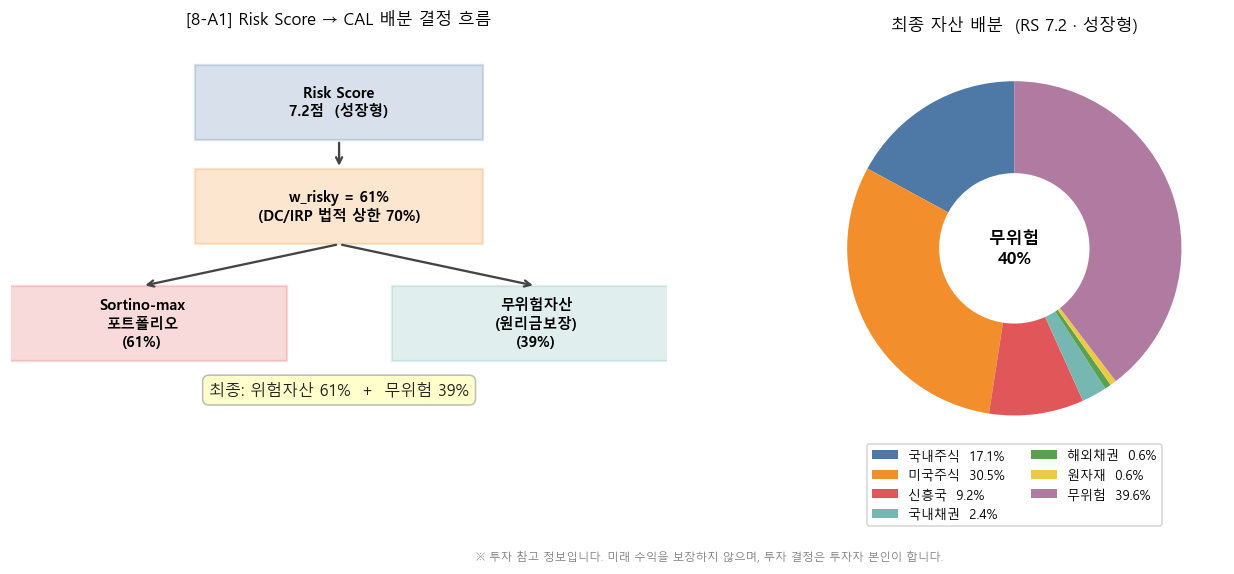


슬롯별 비중 (상위만):
  국내주식_코스피                     0.6%
  국내주식_코스닥                     16.5%
  미국주식_SP500                   6.1%
  미국주식_나스닥                     24.4%
  신흥국_인도                       0.6%
  신흥국_중국                       8.5%
  국내채권_국고채단중기                  0.6%
  국내채권_국고채장기                   0.6%
  국내채권_회사채                     0.6%
  국내채권_종합                      0.6%
  해외채권_미국국채                    0.6%
  원자재_금                        0.6%
  무위험(현금성)                     39.6%


In [4]:
groups = {g: sum(FINAL_W.get(s, 0) for s in slots) for g, slots in SLOTS_GROUPED.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1, 1.2]})

# ── 왼쪽: 흐름 다이어그램 ──
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

boxes = [
    (5, 8.5, f'Risk Score\n{RISK_SCORE:.1f}점  ({TIER})',       '#4e79a7'),
    (5, 6.0, f'w_risky = {W_RISKY*100:.0f}%\n(DC/IRP 법적 상한 70%)', '#f28e2b'),
    (2, 3.2, f'Sortino-max\n포트폴리오\n({W_RISKY*100:.0f}%)',  '#e15759'),
    (8, 3.2, f'무위험자산\n(원리금보장)\n({(1-W_RISKY)*100:.0f}%)', '#76b7b2'),
]
for x, y, txt, c in boxes:
    ax.add_patch(plt.Rectangle((x-2.2, y-0.9), 4.4, 1.8,
                               facecolor=c, alpha=0.22, edgecolor=c, lw=1.5))
    ax.text(x, y, txt, ha='center', va='center', fontsize=9.5, fontweight='bold')

for (x1,y1),(x2,y2) in [((5,7.6),(5,6.9)), ((5,5.1),(2,4.1)), ((5,5.1),(8,4.1))]:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#444'))

ax.text(5, 1.5, f'최종: 위험자산 {W_RISKY*100:.0f}%  +  무위험 {(1-W_RISKY)*100:.0f}%',
        ha='center', fontsize=10.5, color='#222',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffffcc', edgecolor='#bbb'))
ax.set_title('[8-A1] Risk Score → CAL 배분 결정 흐름', fontsize=11, pad=10)

# ── 오른쪽: 최종 배분 도넛 ──
ax2 = axes[1]
vals   = [v for v in groups.values() if v > 0.001]
labels = [k for k, v in groups.items() if v > 0.001]
colors = [GROUP_COLORS[i] for i, (k,v) in enumerate(groups.items()) if v > 0.001]
wedges, _ = ax2.pie(vals, colors=colors, startangle=90,
                    wedgeprops=dict(width=0.55))
ax2.text(0, 0, f"무위험\n{groups['무위험']*100:.0f}%",
         ha='center', va='center', fontsize=11, fontweight='bold')
ax2.legend(wedges, [f"{l}  {v*100:.1f}%" for l,v in zip(labels,vals)],
           loc='lower center', ncol=2, fontsize=8.5, bbox_to_anchor=(0.5,-0.18))
ax2.set_title(f'최종 자산 배분  (RS {RISK_SCORE:.1f} · {TIER})', fontsize=11)

fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

# 슬롯별 상세 비중 출력
print(f"\n슬롯별 비중 (상위만):")
for slot in cur_w.index:
    w = FINAL_W.get(slot, 0)
    if w > 0.005:
        print(f"  {slot:<28} {w*100:.1f}%")

---
## 8-A4 손실 감내도

추상적인 MDD(%)를 현재 적립금 기준 **금액**으로 변환합니다.

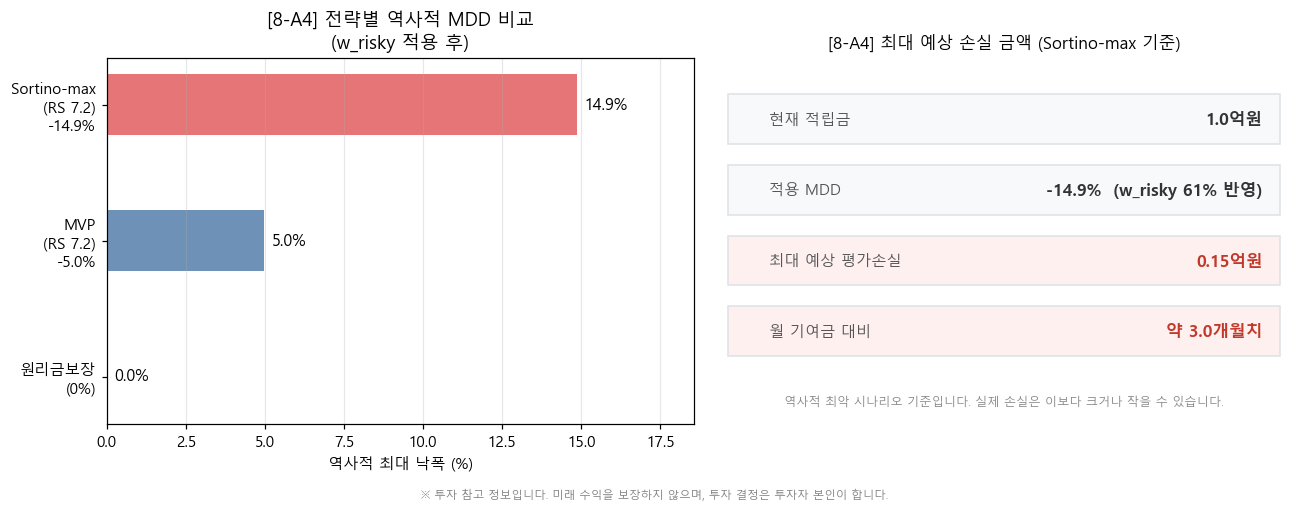

Sortino-max 전체 MDD : -24.35%
CAL 적용 후 MDD      : -14.85%  (= -24.35% × w_risky 61%)
최대 예상 손실       : 0.15억원  (3.0개월치 기여금)


In [5]:
# CAL 적용 후 실질 MDD (무위험 부분은 손실 없음)
cal_mdd_con = MDD_CON * W_RISKY
cal_mdd_mvp = MDD_MVP * W_RISKY
loss_krw    = CURRENT_BALANCE * abs(cal_mdd_con)
loss_months = loss_krw / (ANNUAL_SALARY / 12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── 왼쪽: MDD 바 차트 ──
ax = axes[0]
categories = ['원리금보장\n(0%)',
               f'MVP\n(RS {RISK_SCORE:.1f})\n{cal_mdd_mvp*100:.1f}%',
               f'Sortino-max\n(RS {RISK_SCORE:.1f})\n{cal_mdd_con*100:.1f}%']
mdd_vals   = [0, abs(cal_mdd_mvp)*100, abs(cal_mdd_con)*100]
bar_colors = ['#76b7b2', '#4e79a7', '#e15759']
bars = ax.barh(categories, mdd_vals, color=bar_colors, alpha=0.82, height=0.45)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=10.5)
ax.set_xlabel('역사적 최대 낙폭 (%)')
ax.set_title('[8-A4] 전략별 역사적 MDD 비교\n(w_risky 적용 후)')
ax.set_xlim(0, max(mdd_vals) * 1.25)
ax.grid(axis='x', alpha=0.3)

# ── 오른쪽: 금액 환산 카드 ──
ax2 = axes[1]
ax2.axis('off')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 7)
ax2.set_title('[8-A4] 최대 예상 손실 금액 (Sortino-max 기준)', fontsize=11)

cards = [
    ('현재 적립금',        f'{CURRENT_BALANCE/1e4:.1f}억원',          '#f8f9fa'),
    ('적용 MDD',          f'{cal_mdd_con*100:.1f}%  (w_risky {W_RISKY*100:.0f}% 반영)', '#f8f9fa'),
    ('최대 예상 평가손실', f'{loss_krw/1e4:.2f}억원',                  '#fff0f0'),
    ('월 기여금 대비',     f'약 {loss_months:.1f}개월치',              '#fff0f0'),
]
for i, (label, val, bg) in enumerate(cards):
    y = 5.8 - i * 1.35
    ax2.add_patch(plt.Rectangle((0.3, y-0.45), 9.4, 0.95,
                                facecolor=bg, edgecolor='#dee2e6', lw=1, zorder=2))
    ax2.text(1.0, y, label, va='center', fontsize=10, color='#555', zorder=3)
    color = '#c0392b' if bg == '#fff0f0' else '#333'
    ax2.text(9.4, y, val, va='center', fontsize=11, ha='right',
             fontweight='bold', color=color, zorder=3)

ax2.text(5, 0.35,
         '역사적 최악 시나리오 기준입니다. 실제 손실은 이보다 크거나 작을 수 있습니다.',
         ha='center', fontsize=8, color='#888', style='italic')

fig.text(0.5, -0.02, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

print(f"Sortino-max 전체 MDD : {MDD_CON*100:.2f}%")
print(f"CAL 적용 후 MDD      : {cal_mdd_con*100:.2f}%  (= {MDD_CON*100:.2f}% × w_risky {W_RISKY*100:.0f}%)")
print(f"최대 예상 손실       : {loss_krw/1e4:.2f}억원  ({loss_months:.1f}개월치 기여금)")

---
## 8-A5 내재 위험회피계수 (λ_implied)

투자자가 선택한 `w_risky`에 내재된 위험회피 수준을 시장 기준(λ=3.0)과 비교합니다.

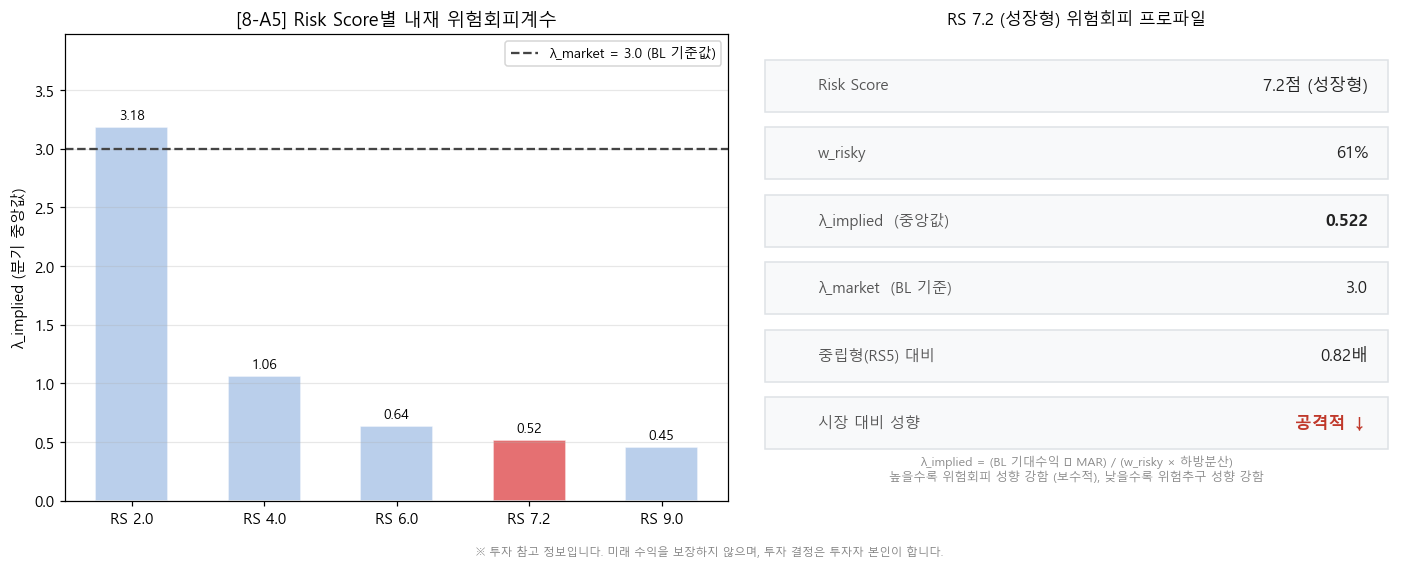

In [6]:
LAMBDA_MARKET = 3.0

# 가장 가까운 데모 Risk Score의 λ 분포 사용
demo_rs  = lam_df['risk_score'].unique()
near_rs  = demo_rs[np.argmin(np.abs(demo_rs - RISK_SCORE))]
sub      = lam_df[lam_df['risk_score'] == near_rs]['lambda_implied'].dropna()
lam_med  = float(sub.median())

# 전체 RS별 중앙값
lam_by_rs = lam_df.groupby('risk_score')['lambda_implied'].median().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: RS별 λ 중앙값 바 ──
ax = axes[0]
rs_list  = lam_by_rs.index.tolist()
lv_list  = lam_by_rs.values.tolist()
bar_c    = ['#e15759' if abs(rs - near_rs) < 0.1 else '#aec7e8' for rs in rs_list]
bars     = ax.bar([f'RS {rs:.1f}' for rs in rs_list], lv_list,
                  color=bar_c, alpha=0.85, width=0.55, edgecolor='white')
ax.axhline(LAMBDA_MARKET, ls='--', color='#444', lw=1.5,
           label=f'λ_market = {LAMBDA_MARKET} (BL 기준값)')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_ylabel('λ_implied (분기 중앙값)')
ax.set_title('[8-A5] Risk Score별 내재 위험회피계수')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(lv_list) * 1.25)

# ── 오른쪽: 해당 투자자 프로파일 카드 ──
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 9); ax2.axis('off')
ax2.set_title(f'RS {RISK_SCORE:.1f} ({TIER}) 위험회피 프로파일', fontsize=11)

direction   = '보수적 ↑' if lam_med > LAMBDA_MARKET else '공격적 ↓'
dir_color   = '#2471a3' if lam_med > LAMBDA_MARKET else '#c0392b'
neutral_lam = float(lam_by_rs.get(5.0, lam_by_rs.iloc[len(lam_by_rs)//2]))
rel_to_neut = lam_med / neutral_lam if neutral_lam > 0 else float('nan')

cards = [
    ('Risk Score',          f'{RISK_SCORE:.1f}점 ({TIER})'),
    ('w_risky',             f'{W_RISKY*100:.0f}%'),
    ('λ_implied  (중앙값)', f'{lam_med:.3f}'),
    ('λ_market  (BL 기준)', f'{LAMBDA_MARKET:.1f}'),
    ('중립형(RS5) 대비',    f'{rel_to_neut:.2f}배'),
    ('시장 대비 성향',      direction),
]
for i, (label, val) in enumerate(cards):
    y = 8.0 - i * 1.3
    ax2.add_patch(plt.Rectangle((0.3, y-0.5), 9.4, 1.0,
                                facecolor='#f8f9fa', edgecolor='#dee2e6', lw=1))
    ax2.text(1.1, y, label, va='center', fontsize=10, color='#555')
    c  = dir_color if label == '시장 대비 성향' else '#222'
    fw = 'bold' if label in ('시장 대비 성향', 'λ_implied  (중앙값)') else 'normal'
    ax2.text(9.4, y, val, va='center', fontsize=11, ha='right', color=c, fontweight=fw)

ax2.text(5, 0.4,
         'λ_implied = (BL 기대수익 − MAR) / (w_risky × 하방분산)\n'
         '높을수록 위험회피 성향 강함 (보수적), 낮을수록 위험추구 성향 강함',
         ha='center', fontsize=8, color='#888', style='italic')

fig.text(0.5, -0.02, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

---
## 8-A6 MVP vs Sortino-max 비교

두 전략의 누적 수익률·MDD·소르티노를 비교해 투자자 성향에 맞는 전략을 안내합니다.

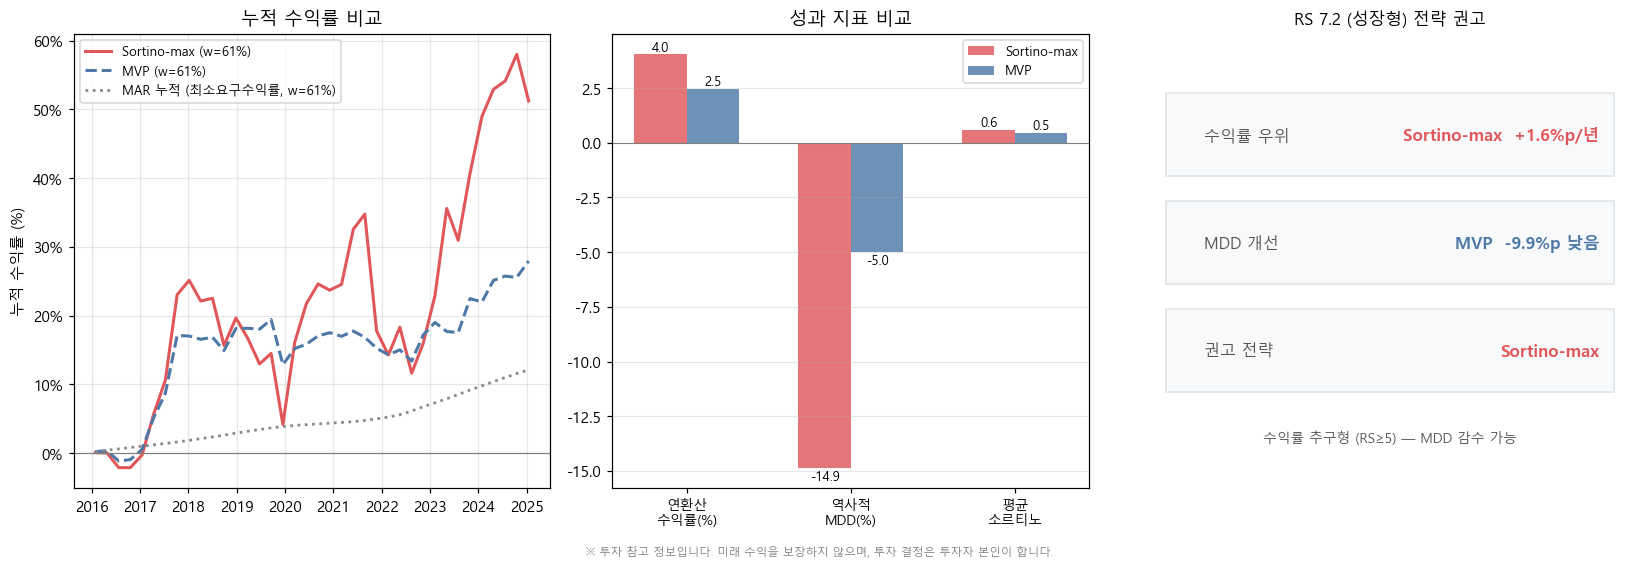


Sortino-max: 연환산 4.04%  MDD -14.85%
MVP        : 연환산 2.47%  MDD -4.97%
수익률 우위: Sortino-max +1.57%p/년
MDD 개선   : MVP -9.88%p 낮음
권고 전략  : Sortino-max


In [7]:
# CAL 적용 누적 수익률 (무위험 초과수익 ≈ 0 가정)
cal_cum_con = (cum_con - 1) * W_RISKY * 100
cal_cum_mvp = (cum_mvp - 1) * W_RISKY * 100

# MAR 누적 기준선 (최소요구수익률 복리 누적, CAL 스케일 적용)
mar_q_rate  = perf_con['mar_annual_pct'] / 100 / 4   # 분기 수익률
cal_cum_mar = ((1 + mar_q_rate).cumprod() - 1) * W_RISKY * 100

ret_diff = (ANN_RET_CON - ANN_RET_MVP) * W_RISKY * 100
mdd_diff = (abs(cal_mdd_mvp) - abs(cal_mdd_con)) * 100   # 양수 = MVP가 MDD 낮음
recommend = 'Sortino-max' if RISK_SCORE >= 5 else 'MVP'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 누적 수익률 시계열 ──
ax = axes[0]
ax.plot(cal_cum_con.index, cal_cum_con.values, color='#e15759', lw=2,
        label=f'Sortino-max (w={W_RISKY*100:.0f}%)')
ax.plot(cal_cum_mvp.index, cal_cum_mvp.values, '--', color='#4e79a7', lw=2,
        label=f'MVP (w={W_RISKY*100:.0f}%)')
ax.plot(cal_cum_mar.index, cal_cum_mar.values, ':', color='#888888', lw=1.8,
        label=f'MAR 누적 (최소요구수익률, w={W_RISKY*100:.0f}%)')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('누적 수익률 (%)')
ax.set_title('누적 수익률 비교')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}%'))

# ── 성과 지표 바 차트 ──
ax2 = axes[1]
metrics  = ['연환산\n수익률(%)', '역사적\nMDD(%)', '평균\n소르티노']
con_vals = [ANN_RET_CON*W_RISKY*100, cal_mdd_con*100, float(perf_con['sortino'].mean())]
mvp_vals = [ANN_RET_MVP*W_RISKY*100, cal_mdd_mvp*100, float(perf_mvp['sortino'].mean())]

x = np.arange(len(metrics))
w = 0.32
b1 = ax2.bar(x - w/2, con_vals, w, label='Sortino-max', color='#e15759', alpha=0.82)
b2 = ax2.bar(x + w/2, mvp_vals, w, label='MVP',          color='#4e79a7', alpha=0.82)
ax2.set_xticks(x); ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_title('성과 지표 비교')
ax2.axhline(0, color='gray', lw=0.7)
ax2.legend(fontsize=8.5); ax2.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    v = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.15 if v >= 0 else -0.6),
             f'{v:.1f}', ha='center', fontsize=8.5)

# ── 전략 권고 카드 ──
ax3 = axes[2]
ax3.axis('off')
ax3.set_xlim(0, 10); ax3.set_ylim(0, 8)
ax3.set_title(f'RS {RISK_SCORE:.1f} ({TIER}) 전략 권고', fontsize=11)

rec_color = '#e15759' if recommend == 'Sortino-max' else '#4e79a7'
items = [
    ('수익률 우위', f'Sortino-max  +{ret_diff:.1f}%p/년', '#e15759'),
    ('MDD 개선',   f'MVP  {mdd_diff:.1f}%p 낮음',         '#4e79a7'),
    ('권고 전략',  recommend,                              rec_color),
]
for i, (label, val, color) in enumerate(items):
    y = 6.2 - i * 1.9
    ax3.add_patch(plt.Rectangle((0.3, y-0.7), 9.4, 1.45,
                                facecolor='#f8f9fa', edgecolor='#dee2e6', lw=1))
    ax3.text(1.1, y, label, va='center', fontsize=10.5, color='#555')
    ax3.text(9.4, y, val, va='center', fontsize=11, ha='right',
             color=color, fontweight='bold')

reason = ('수익률 추구형 (RS≥5) — MDD 감수 가능'
          if RISK_SCORE >= 5 else '안정추구형 (RS<5) — MDD 최소화 우선')
ax3.text(5, 0.8, reason, ha='center', fontsize=9, color='#555', style='italic')

fig.text(0.5, -0.02, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

print(f"\nSortino-max: 연환산 {ANN_RET_CON*W_RISKY*100:.2f}%  MDD {cal_mdd_con*100:.2f}%")
print(f"MVP        : 연환산 {ANN_RET_MVP*W_RISKY*100:.2f}%  MDD {cal_mdd_mvp*100:.2f}%")
print(f"수익률 우위: Sortino-max +{ret_diff:.2f}%p/년")
print(f"MDD 개선   : MVP {mdd_diff:.2f}%p 낮음")
print(f"권고 전략  : {recommend}")